In [19]:
#去除2026年的数据
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,accuracy_score
data=pd.read_csv('DATA.csv')
data_clean = data[data['year'] != 2026].copy()
data_clean['high_impact'] = (data_clean['NCC'] >= 1.0).astype(int)
cols=['MWL', 'LC', 'LD', 'ASL', 'JD', 'HD']
X=data_clean[cols]
y=data_clean['high_impact']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
clf=DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.64      0.93      0.76        46
           1       0.25      0.04      0.07        25

    accuracy                           0.62        71
   macro avg       0.45      0.49      0.42        71
weighted avg       0.50      0.62      0.52        71

0.6197183098591549


In [18]:
#保留2026年的数据
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,accuracy_score
data=pd.read_csv('DATA.csv')
data['high_impact'] = (data['NCC'] >= 1.0).astype(int)
cols=['MWL', 'LC', 'LD', 'ASL', 'JD', 'HD']
X=data[cols]
y=data['high_impact']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
clf=DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.63      0.80      0.71        50
           1       0.23      0.12      0.15        26

    accuracy                           0.57        76
   macro avg       0.43      0.46      0.43        76
weighted avg       0.50      0.57      0.52        76

0.5657894736842105


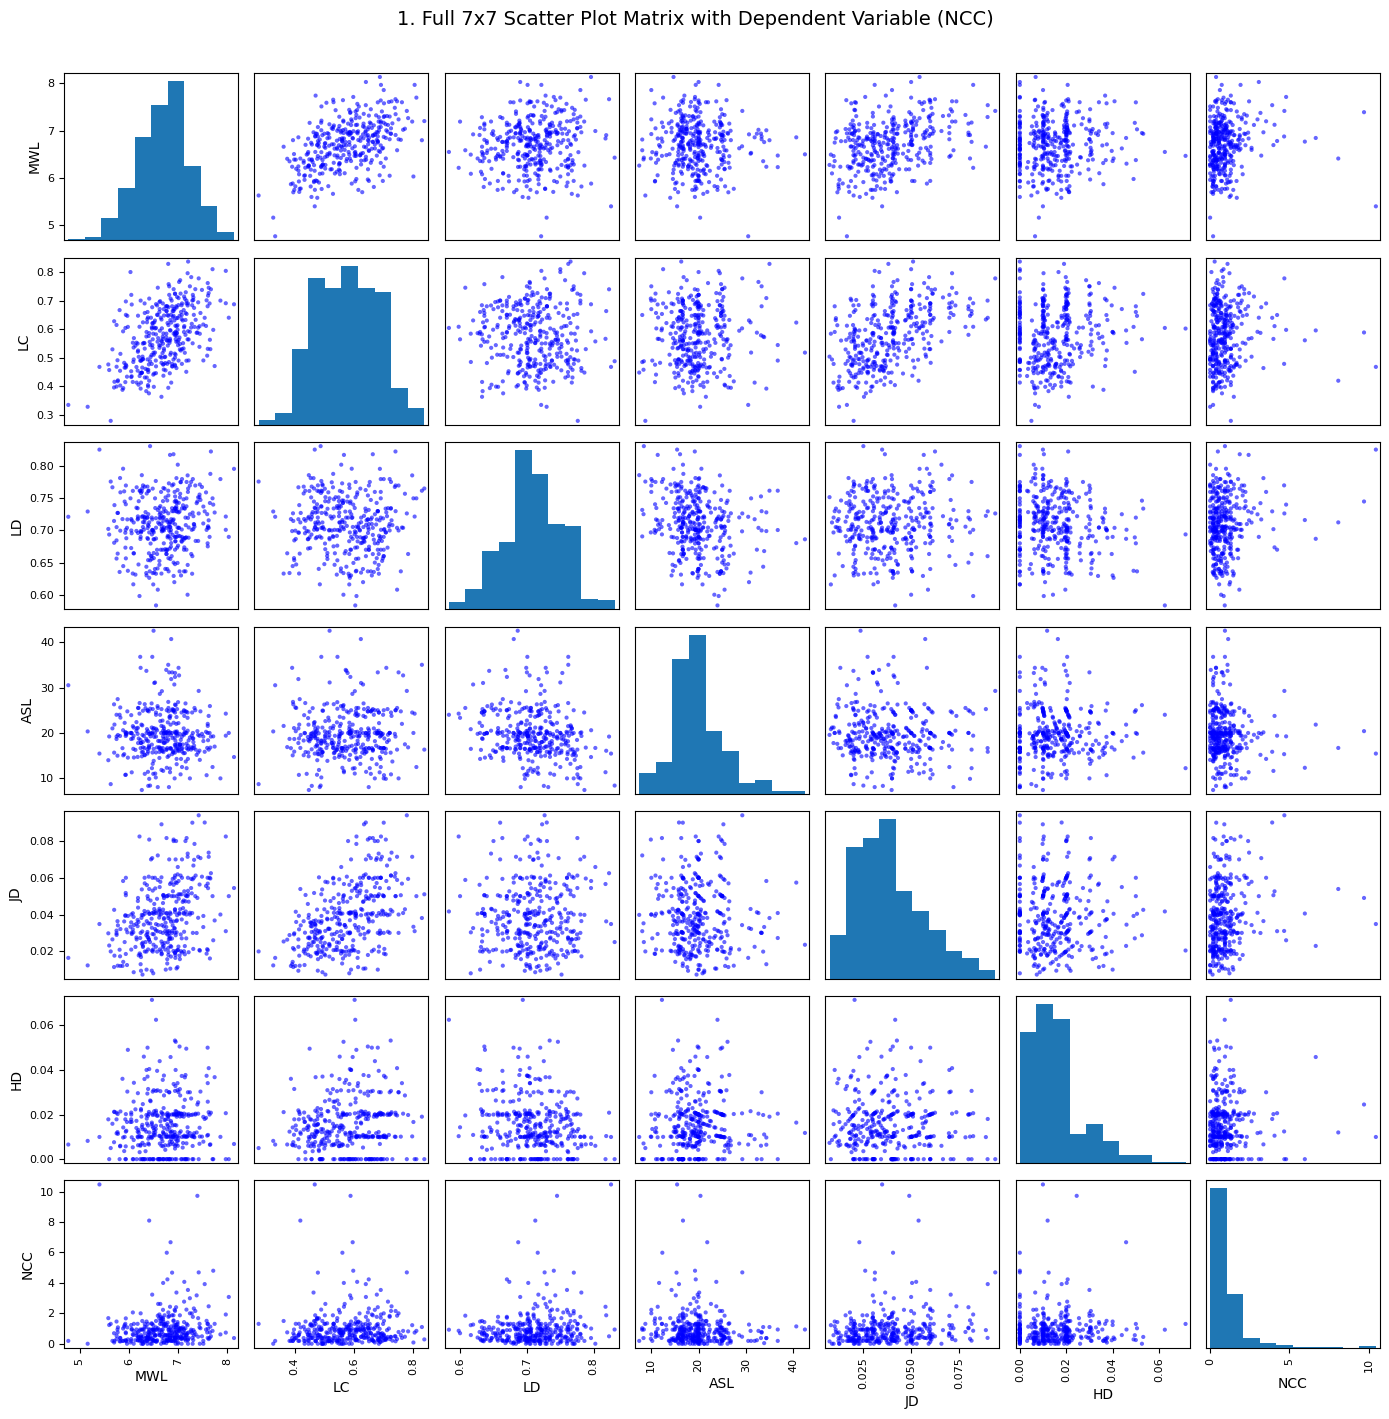

In [27]:
#散点图矩阵
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,accuracy_score
import matplotlib.pyplot as plt
data=pd.read_csv('DATA.csv')
data_clean = data[data['year'] != 2026].copy()
data_clean['high_impact'] = (data_clean['NCC'] >= 1.0).astype(int)
cols=['MWL', 'LC', 'LD', 'ASL', 'JD', 'HD']
X=data_clean[cols]
y=data_clean['high_impact']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
clf=DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
xdata = data_clean[cols + ['NCC']]
pd.plotting.scatter_matrix(xdata, diagonal='hist', color='b', figsize=(14, 14), alpha=0.6)
plt.suptitle('1. Full 7x7 Scatter Plot Matrix with Dependent Variable (NCC)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('散点图矩阵', dpi=300, bbox_inches='tight')
plt.show()

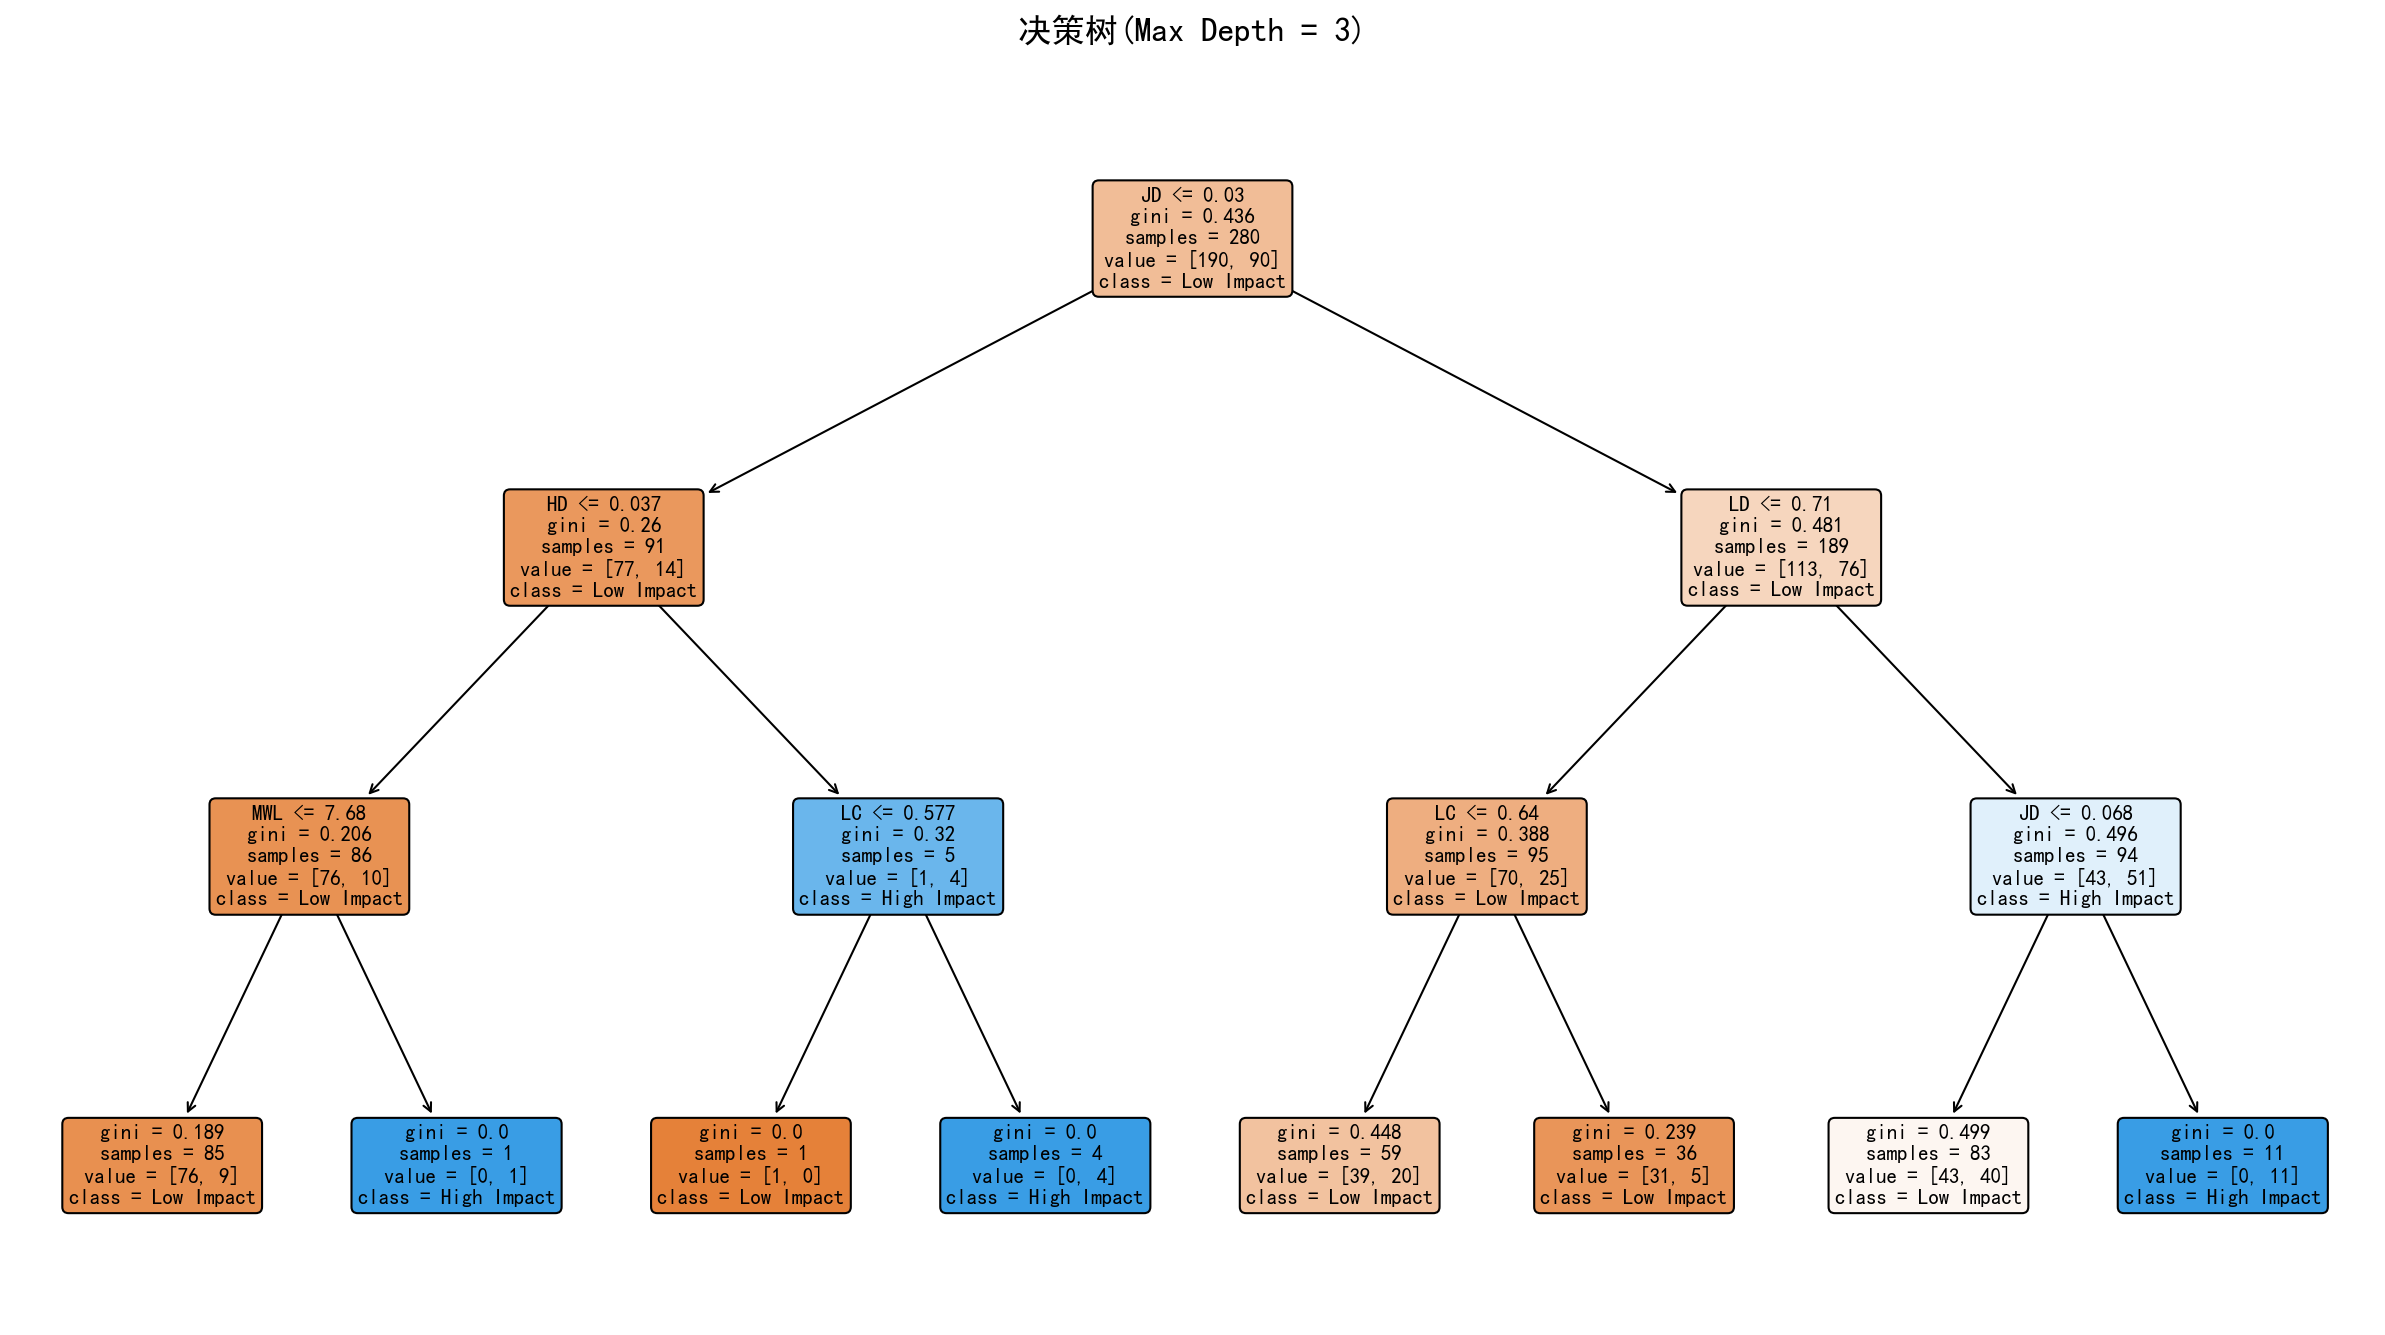

In [32]:
#决策树图像
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import classification_report,accuracy_score
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(16, 9), dpi=150)
plot_tree(clf, feature_names=cols, class_names=['Low Impact', 'High Impact'], filled=True, rounded=True,fontsize=10)
plt.title('决策树(Max Depth = 3)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('决策树', dpi=300, bbox_inches='tight')

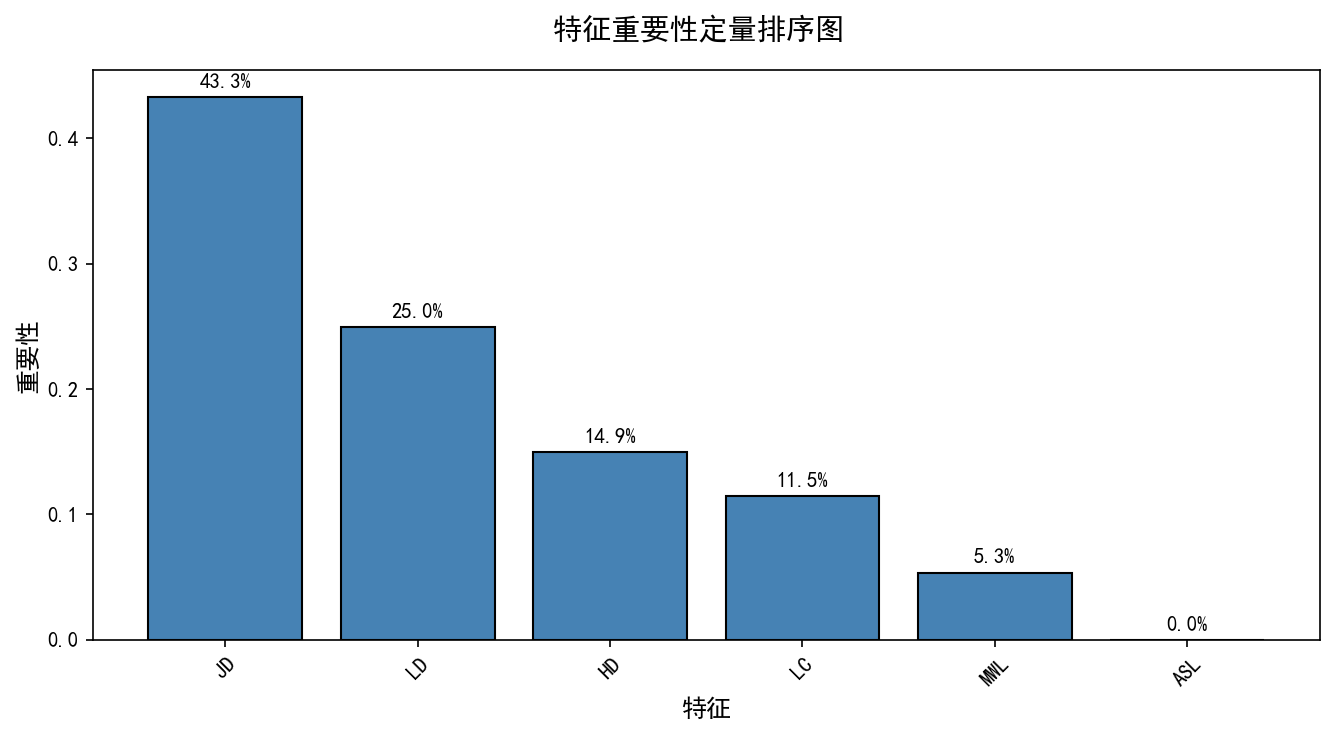

In [36]:
#特征重要性柱状图
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import classification_report,accuracy_score
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
data=pd.read_csv('DATA.csv')
data_clean = data[data['year'] != 2026].copy()
data_clean['high_impact'] = (data_clean['NCC'] >= 1.0).astype(int)
cols=['MWL', 'LC', 'LD', 'ASL', 'JD', 'HD']
X=data_clean[cols]
y=data_clean['high_impact']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
clf=DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
importances = clf.feature_importances_
imp_series = pd.Series(importances, index=cols).sort_values(ascending=False)
plt.figure(figsize=(9, 5), dpi=150)
plt.bar(imp_series.index, imp_series.values, align="center", color='steelblue', edgecolor='black')
plt.title('特征重要性定量排序图 ', fontsize=14, pad=15)
plt.xlabel('特征', fontsize=12)
plt.ylabel('重要性', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(imp_series.values):
    plt.text(i, v + 0.005, f"{v:.1%}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('特征重要性', dpi=300, bbox_inches='tight')
